In [ ]:
#| default_exp laggedCc_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

In [ ]:
#| hide

from fhemb.piece import Piece
from fhemb.utils.factories import wfactory, pca_factory

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths


DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db


In [ ]:
#| hide
from fhemb.piece import Piece
from fhemb.embedding import EmbeddingCollection 
from fhemb.utils.factories import pca_factory, wfactory
from fhemb.utils.factories import ConcreteEmbFactory, ConcretePcaFactory, wfactory
from nbdev import show_doc

# Lagged Cross Correlations

## Graphs

We demnstrate the usage of the `lagged_correlations` method of the `EmbeddingCollection` class.
It can be used in two ways: 

1. between two features of a subject or 

2. between two subjects on the same feature.

In [ ]:
#| eval: false
from nbdev_fhemb.embedding_ex import dg0, pca

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 42), 50, (65, 68)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 50, 65, 66, 67, 68] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 50, 65, 66, 67, 68]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 42), 50, (65, 68)]
 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj40, subj41, subj42, subj50, subj65, subj66, subj67, subj68 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 15200 ORDER BY frame_num

 [DEBUG] piece.project: Choosen embeddings: [('percentiles_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['p45']}), ('features_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['median']})]
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mixins.wrapper: Processing features ['p45'], heatmap None, fvector None, args=(), and kwargs={'factory': <fhemb.utils.factories.ConcreteEmbFactory object>}
 [DEBUG] mixins.wrapper: Percentile features detected, after preprocessing: [9]
 [DEBUG] mixins.wrapper: Validating feature: [9]
 [DEBUG] mixins.validate_grid: Vallidating grid: [9] and maxsize: 21
 [DEBUG] mixins.validate_grid: Vallidated grid: [9]
 [DEBUG] mixins.wrapper: valid_feature: [9]
 [DEBUG] mixins.wrapper: valid_features=[9]
 [DEBUG] embedding._create_wdecomposition_impl: Calling create_wdecomposition for features=('p45',)
 [DEBUG] tutils.create: Creating create_wdecomposition with args: ('p45',) and kwargs: di

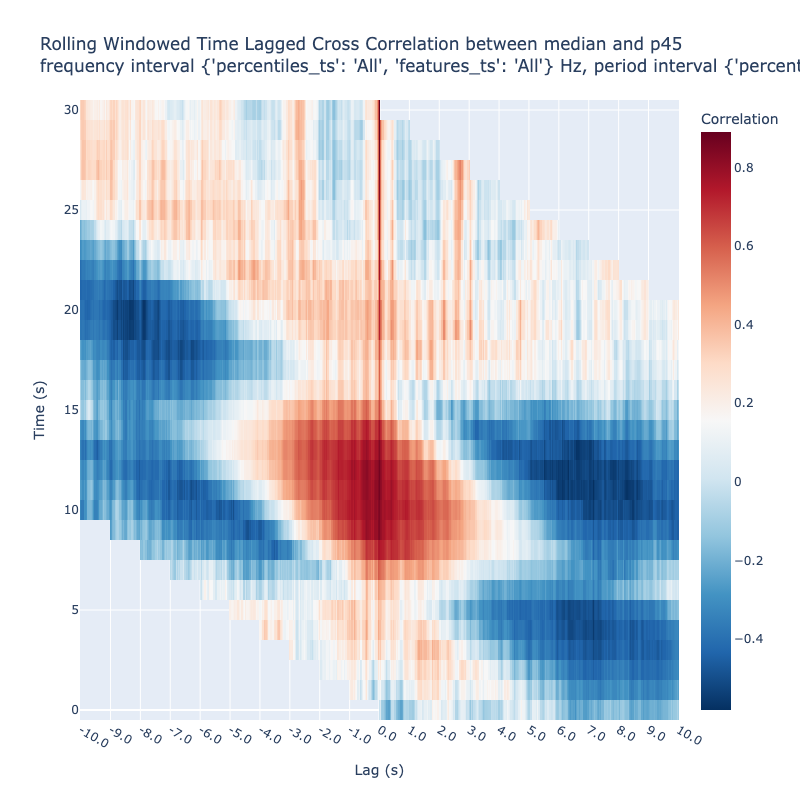

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[65],                    # Subject of interest   
    features=['p45', 'median'],    # Features to be cross-correlated
    wdfactory=wfactory('db4',8),   # Specify the wavelet transform in case of wavelet analysis 
).plot_lagged_correlations(
    twin=250,         # Time window in frames
    step=25,          # Step size in frames
    max_lag=250,      # Maximum lag in frames
)

::: {.callout-note}
Note that cross-correlation between median and 50-percentile would be effectively autocorrelation. It is expected that the cross-correlation between the median and 45-percentile have a similar pattern.  
:::

 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])
 [DEBUG] tutils.create: Using already calculated value for StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)
 [DEBUG] piece.project: Choosen embeddings: [('pcomponents_ts', {'embedding': <fhemb.

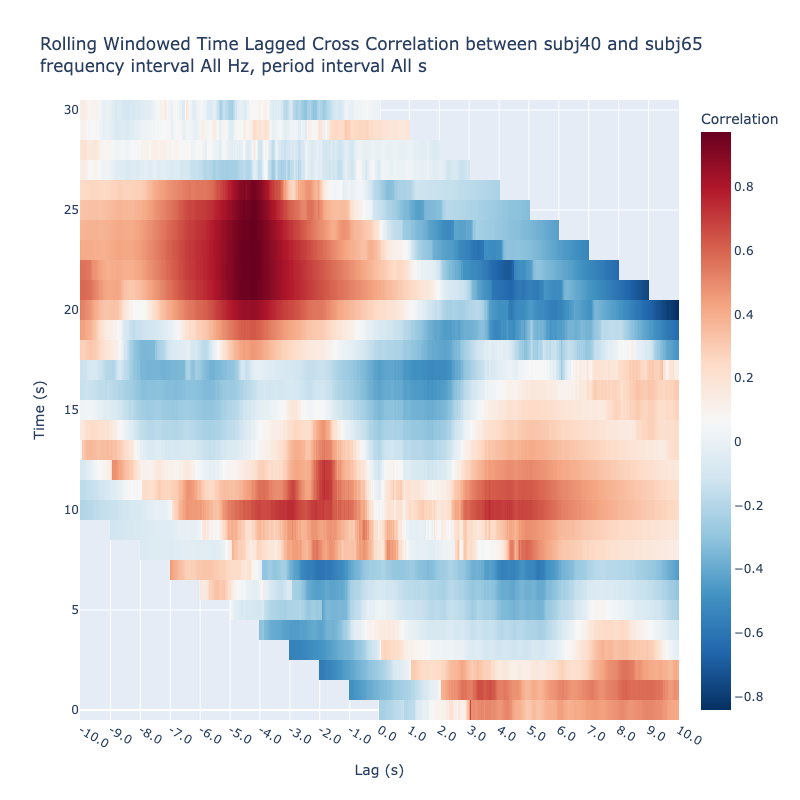

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[40,65],                # Specify subjects to be cross-correlated
    features=['pc0'],             # on a single feature - principle component 0
    wdfactory=wfactory('db4',8),  # Specify the wavelet transform in case wavelet analysis is needed
    pcfactory=pca,                # Specify the PCA  
).plot_lagged_correlations(
    twin=250,                     # Time window in frames 
    step=25,                      # Step size in frames
    max_lag=250,                  # Maximum lag in frames
)

 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])
 [DEBUG] tutils.create: Using already calculated value for StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)
 [DEBUG] piece.project: Choosen embeddings: [('percentiles_ts', {'embedding': <fhemb.

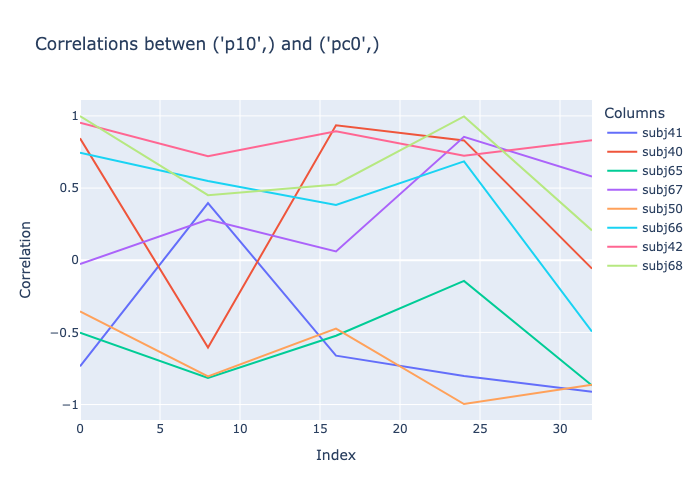

In [ ]:
#| eval: false

dg0.face_t.project(
    features=['pc0', 'p10'],      # on a single feature - principle component 0
    wdfactory=wfactory('db4',8),  # Specify the wavelet transform in case wavelet analysis is needed
    pcfactory=pca,                # Specify the PCA  
).lagged_correlation_graph(
    twin=50,                      # Time window in frames
    step=200,                     # Step size in frames
    max_lag=2,                    # Maximum lag in frames
)

## Numeric Values

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[40,65],                # Specify subjects to be cross-correlated
    features=['pc0'],             # on a single feature - principle component 0
    wdfactory=wfactory('db4',8),  # Specify the wavelet transform in case wavelet analysis is needed
    pcfactory=pca,                # Specify the PCA  
).lagged_correlations_df(
    twin=50,                      # Time window in frames
    step=200,                     # Step size in frames
    max_lag=2,                    # Maximum lag in frames
)

 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])
 [DEBUG] tutils.create: Using already calculated value for StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)
 [DEBUG] piece.project: Choosen embeddings: [('pcomponents_ts', {'embedding': <fhemb.

{'df': {'pc0':         lag_-2    lag_-1     lag_0     lag_1     lag_2
  0.0        NaN       NaN  0.031109  0.040759  0.045263
  8.0   0.446141  0.480165  0.512525  0.547122  0.602246
  16.0 -0.158507 -0.189139 -0.188891 -0.178513 -0.248553
  24.0  0.238015  0.210797  0.173822  0.122175  0.054478
  32.0 -0.185682 -0.176506 -0.191112  0.060872  0.198622}}